In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("data/survey_results_public.csv")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
df.head()

Number of Rows: 49191
Number of Columns: 172


C:\Users\RPCO\AppData\Local\Temp\ipykernel_10772\189809255.py:6: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/survey_results_public.csv")


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [2]:
#List all Columns
print(df.columns.tolist())

['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechEndorse_13_TEXT', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'TechOppose_15_TEXT', 'Industry', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 'AIThreat', 'NewRole', 'ToolCountWork', 'ToolCountPersona

In [3]:
#Select the important columns for analysis
important_columns = ['ConvertedCompYearly', 'YearsCode', 'Country', 'EdLevel', 'RemoteWork', 'Age', 'LanguageHaveWorkedWith', 'DevType', 'OrgSize']
df_subset = df[important_columns]

#check for missing values
print(df_subset.isnull().sum())
print(f"\nrows with salary data: {df_subset['ConvertedCompYearly'].notnull().sum()}out of {len(df_subset)}")

ConvertedCompYearly       25244
YearsCode                  6149
Country                   13754
EdLevel                    1042
RemoteWork                15411
Age                           0
LanguageHaveWorkedWith    17520
DevType                    5511
OrgSize                   15013
dtype: int64

rows with salary data: 23947out of 49191


In [4]:
#1 Remove rows with missing salary data 
df_clean = df_subset.dropna(subset=['ConvertedCompYearly'])

print(f"\nrows with salary data after cleaning:{len(df_clean)}")


rows with salary data after cleaning:23947


In [5]:
#2 checking missing values 
missing_values = (df_clean.isnull().sum() / len(df_clean)) * 100
print(missing_values.sort_values(ascending=False))

RemoteWork                11.905458
OrgSize                   11.454462
LanguageHaveWorkedWith     7.625172
YearsCode                  0.455172
EdLevel                    0.070990
ConvertedCompYearly        0.000000
Country                    0.000000
Age                        0.000000
DevType                    0.000000
dtype: float64


In [6]:
#Drop rows with less than 10% missing values
df_clean = df_clean.dropna(subset=['EdLevel', 'YearsCode', 'LanguageHaveWorkedWith'])

#Filling columns with more missing values with 'Unknown'
df_clean['RemoteWork'] = df_clean['RemoteWork'].fillna('Unknown')
df_clean['OrgSize'] = df_clean['OrgSize'].fillna('Unknown')

print(f"final rows after cleaning: {len(df_clean)}")
print(f"Remaining missing values:\n{df_clean.isnull().sum()}")

final rows after cleaning: 22032
Remaining missing values:
ConvertedCompYearly       0
YearsCode                 0
Country                   0
EdLevel                   0
RemoteWork                0
Age                       0
LanguageHaveWorkedWith    0
DevType                   0
OrgSize                   0
dtype: int64


In [7]:
print(df_clean['ConvertedCompYearly'].describe())

count    2.203200e+04
mean     9.917461e+04
std      2.938612e+05
min      1.000000e+00
25%      4.060500e+04
50%      7.599700e+04
75%      1.225270e+05
max      3.355272e+07
Name: ConvertedCompYearly, dtype: float64


In [8]:
#Finding the 1st and 99th percentile values 
lower_bound = df_clean['ConvertedCompYearly'].quantile(0.01)
upper_bound = df_clean['ConvertedCompYearly'].quantile(0.99)

print(f"1st Percentile: {lower_bound}")
print(f"99th Percentile: {upper_bound}")

#Keep only the rows within the 1st and 99th percentile range
df_final = df_clean [(df_clean['ConvertedCompYearly'] >= lower_bound) & (df_clean['ConvertedCompYearly'] <= upper_bound)]
print(f"final rows after removing outliers: {len(df_final)}")
print(df_final['ConvertedCompYearly'].describe())

1st Percentile: 93.31
99th Percentile: 412759.99999999476
final rows after removing outliers: 21590
count     21590.000000
mean      89559.510236
std       68327.422587
min          94.000000
25%       41518.000000
50%       75997.000000
75%      120448.500000
max      410000.000000
Name: ConvertedCompYearly, dtype: float64


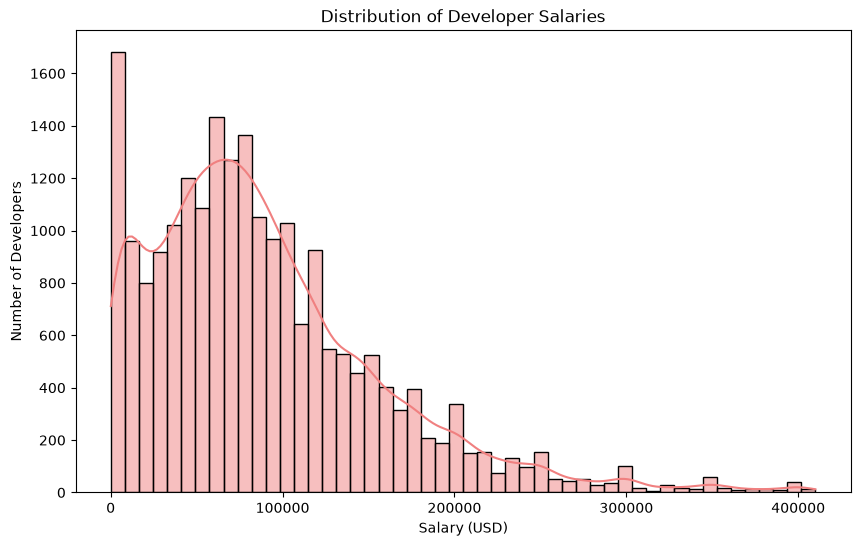

In [9]:
#Creat a histogram to see the distribution of the salary data
plt.figure(figsize=(10, 6))
sns.histplot(df_final['ConvertedCompYearly'], bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Developer Salaries')
plt.xlabel('Salary (USD)')
plt.ylabel('Number of Developers')
plt.show()

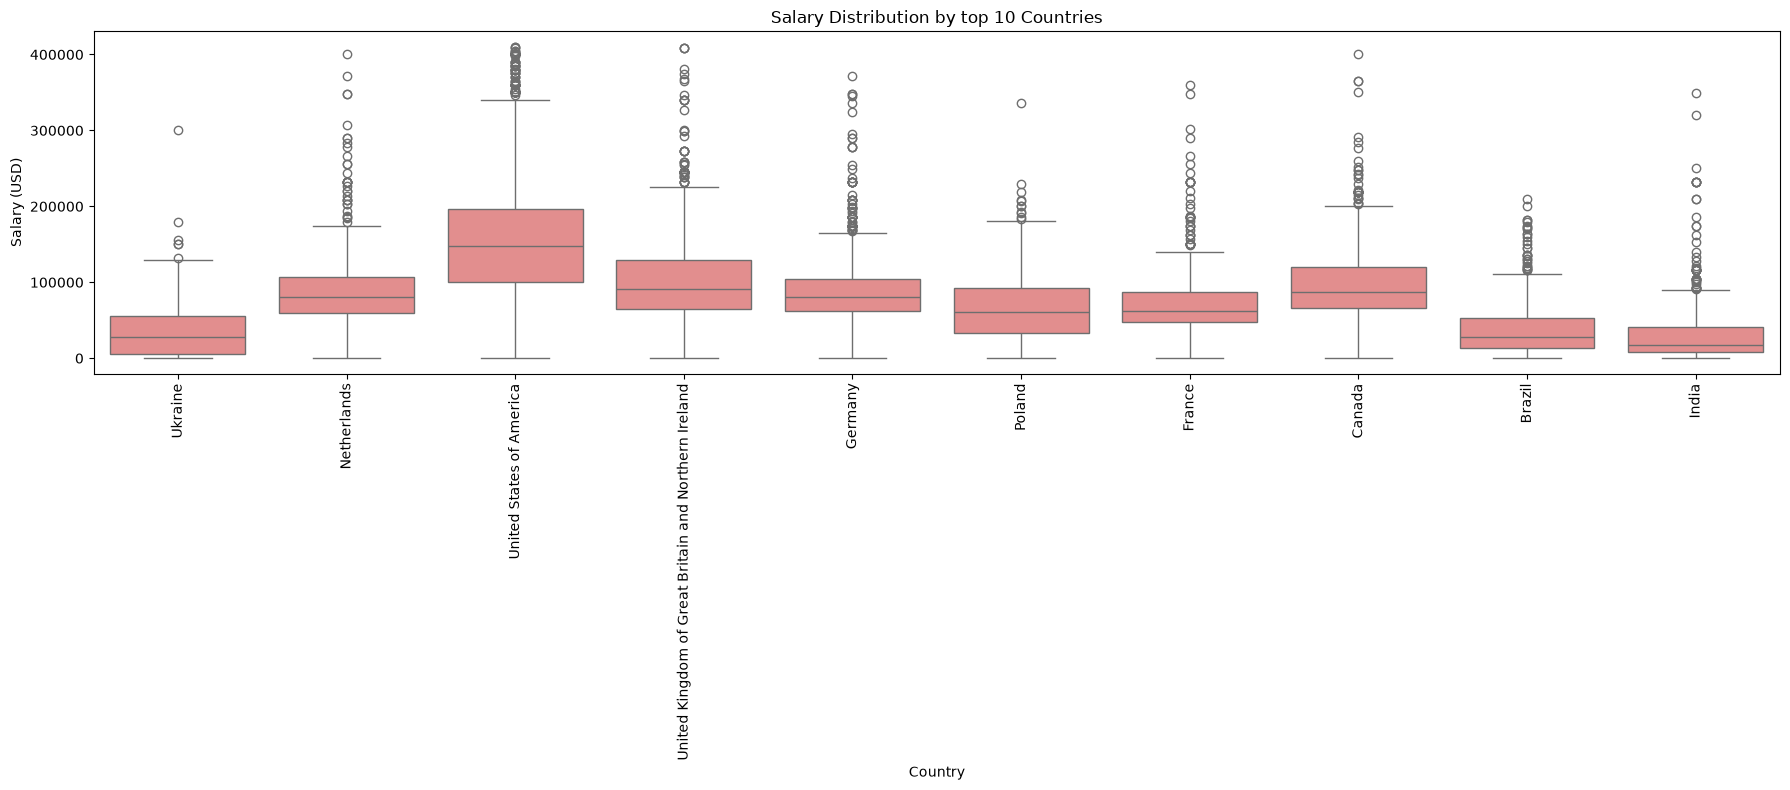

In [10]:
#Select the top 10 countries with the most respondents
top_countries = df_final['Country'].value_counts().head(10).index

#Filter the data to these top countries
df_top_countries = df_final[df_final['Country'].isin(top_countries)]

#Creat a boxplot to visualize the salary distribution by these top countries
plt.figure(figsize=(18, 8))
sns.boxplot(data=df_top_countries, x='Country', y='ConvertedCompYearly', color='lightcoral')
plt.title('Salary Distribution by top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Salary (USD)')
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
#Unique values in YearsCode column

print(df_final['YearsCode'].unique())

[ 14.  10.  12.   5.  22.  20.  13.  30.  15.   9.  11.  41.  36.  23.
  26.  25.   8.  38.  35.  21.  19.  18.  16.  45.  17.  42.  40.  27.
  24.  28.   6.   3.  37.  32.   1.  39.   4.  53.  33.   7.   2.  29.
  50.  48.  44.  31.  46.  43.  47.  52.  34.  51.  58.  57.  54.  49.
  55.  56.  60. 100.  68.  59.  63.  61.]


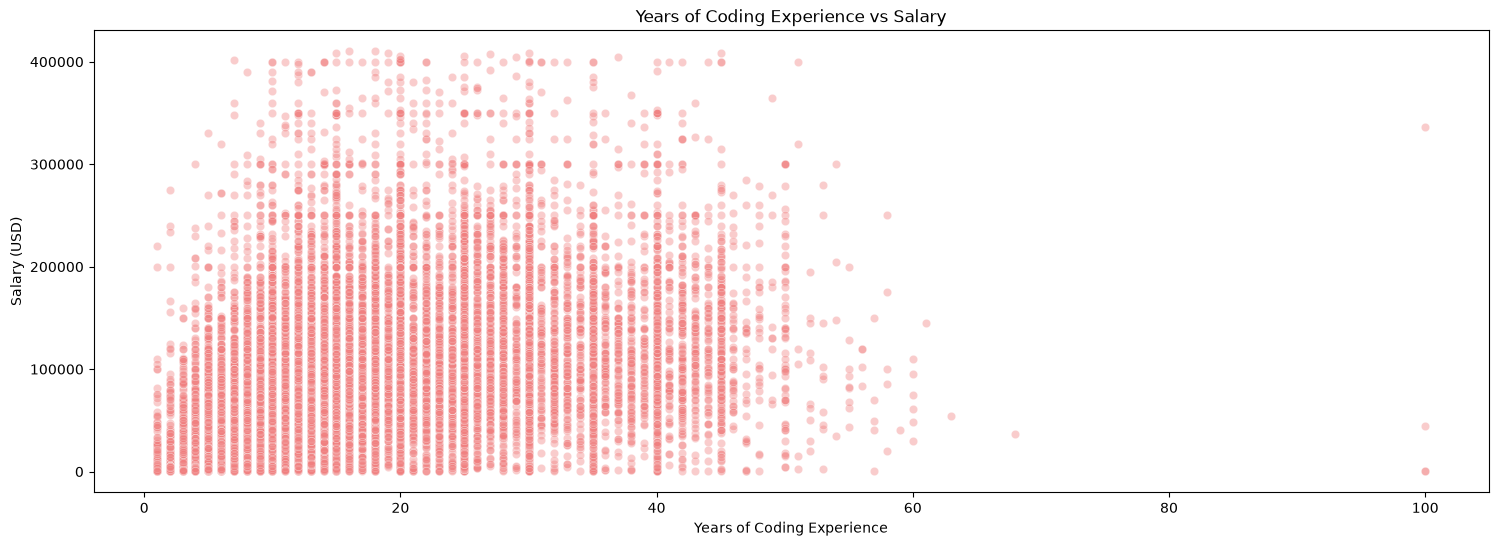

In [12]:
#Create a scatter plot to visualize the relationship between Years of Coding Experience and Salary
plt.figure(figsize=(18, 6))
sns.scatterplot(data=df_final, x='YearsCode', y='ConvertedCompYearly', alpha=0.4, color='lightcoral')
plt.title('Years of Coding Experience vs Salary')
plt.xlabel('Years of Coding Experience')
plt.ylabel('Salary (USD)')
plt.show()

In [13]:
#Checking the data in LanguageHaveWorkedWith column
print(df_final['LanguageHaveWorkedWith'].iloc[:10])

0                      Bash/Shell (all shells);Dart;SQL
1                                                  Java
2                   Dart;HTML/CSS;JavaScript;TypeScript
3                                       Java;Kotlin;SQL
4     C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...
5                                            Java;Scala
6                                 JavaScript;TypeScript
7     Bash/Shell (all shells);HTML/CSS;JavaScript;Py...
8                                     Java;Python;Scala
10              HTML/CSS;Java;JavaScript;SQL;TypeScript
Name: LanguageHaveWorkedWith, dtype: str


In [14]:
#Select the well-known programming languages for analysis and split them
all_languages = df_final['LanguageHaveWorkedWith'].str.split(';').explode()
top_languages = all_languages.value_counts().head(10).index
print(f"Top 10 Programming Languages: {top_languages.tolist()}")

Top 10 Programming Languages: ['JavaScript', 'HTML/CSS', 'SQL', 'Python', 'Bash/Shell (all shells)', 'TypeScript', 'C#', 'Java', 'PowerShell', 'C++']


In [15]:
#Claculate the average salary for each of the top programming languages
lanaguage_salary = {}
for language in top_languages:
    Filter = df_final['LanguageHaveWorkedWith'].str.contains(language, na=False, regex=False)
    avg_salary = df_final.loc[Filter, 'ConvertedCompYearly'].mean()
    lanaguage_salary[language] = avg_salary

#convert them to  a dataframe for plotting
language_salary_df = pd.Series(lanaguage_salary).sort_values(ascending=False)
print(language_salary_df)    

Bash/Shell (all shells)    96494.013743
Python                     92106.113280
TypeScript                 91647.252843
PowerShell                 89743.340523
SQL                        89603.998570
C#                         89387.369392
C++                        88805.670103
Java                       88709.071941
JavaScript                 88147.751563
HTML/CSS                   86087.399556
dtype: float64


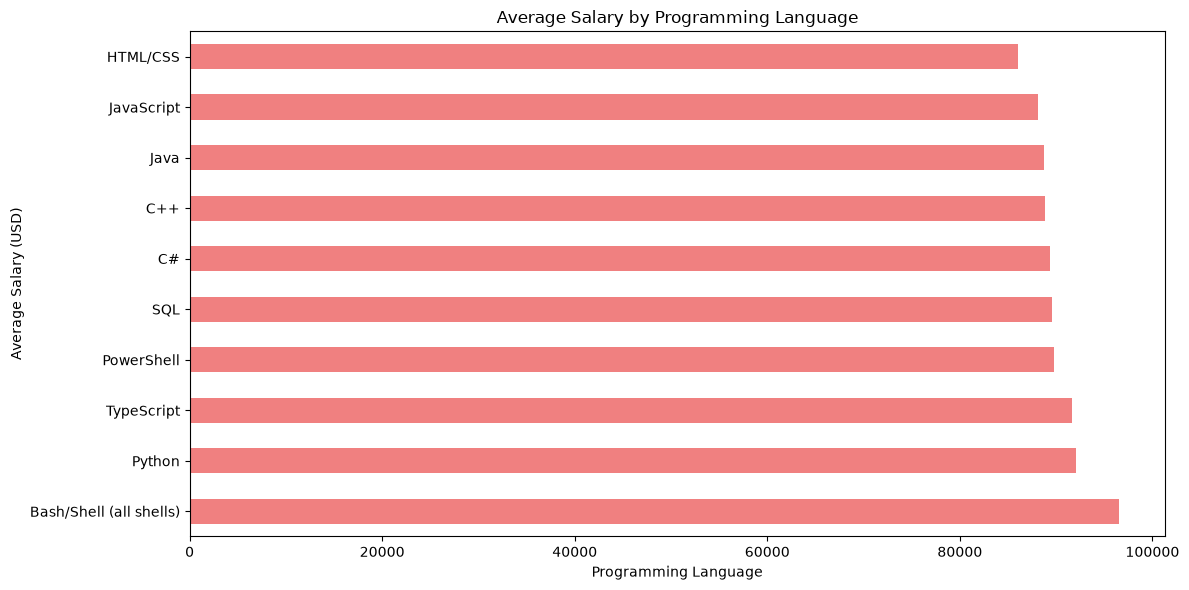

In [16]:
#creat a plot for the average salary of the top programming languages
plt.figure(figsize=(12, 6))
language_salary_df.plot(kind='barh', color='lightcoral')
plt.title('Average Salary by Programming Language')
plt.xlabel('Programming Language')
plt.ylabel('Average Salary (USD)')

plt.tight_layout()
plt.show()

In [17]:
#checking the most common job types in the DevType column
print(df_final['DevType'].value_counts().head(10))

DevType
Developer, full-stack                            6827
Developer, back-end                              3577
Architect, software or solutions                 1471
Developer, desktop or enterprise applications    1043
Developer, front-end                             1026
Developer, embedded applications or devices       713
Other (please specify):                           697
Developer, mobile                                 659
DevOps engineer or professional                   633
Engineering manager                               631
Name: count, dtype: int64


In [18]:
# Keep top 10 job types, excluding the vague "Other" category
top_devtypes = df_final['DevType'].value_counts().head(11).index
top_devtypes = [dt for dt in top_devtypes if 'Other' not in dt]

# Calculate average salary for each top job type
devtype_salary = df_final[df_final['DevType'].isin(top_devtypes)].groupby('DevType')['ConvertedCompYearly'].mean()
devtype_salary = devtype_salary.sort_values(ascending=False)

print(devtype_salary)

DevType
Engineering manager                              140063.757528
Architect, software or solutions                 112382.565602
DevOps engineer or professional                  100136.895735
Developer, back-end                               93095.215823
Developer, embedded applications or devices       89362.098177
Developer, desktop or enterprise applications     85057.348035
Developer, mobile                                 83970.737481
Developer, full-stack                             82865.554123
Developer, front-end                              74798.325536
Academic researcher                               54650.522727
Name: ConvertedCompYearly, dtype: float64


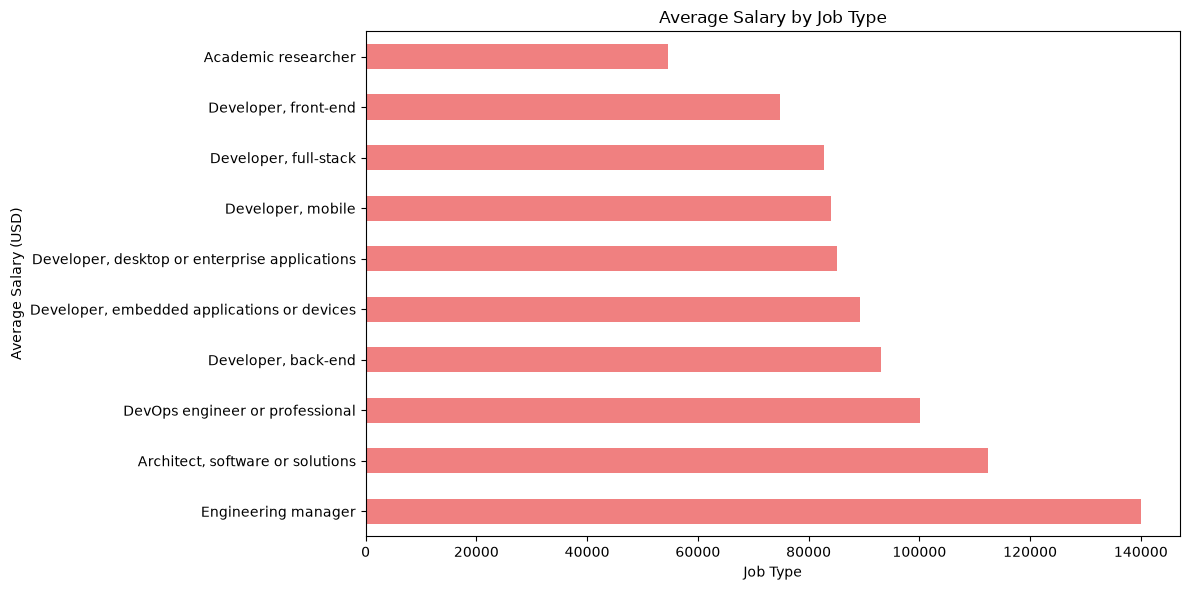

In [19]:
#Creat a plot for the average salary of the top job types
plt.figure(figsize=(12, 6))
devtype_salary.plot(kind='barh', color='lightcoral')
plt.title('Average Salary by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Average Salary (USD)')
plt.tight_layout()
plt.show()

In [20]:
print(df_final['EdLevel'].value_counts())

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          9389
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       6314
Some college/university study without earning a degree                                2580
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                        1232
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)    1074
Associate degree (A.A., A.S., etc.)                                                    723
Other (please specify):                                                                183
Primary/elementary school                                                               95
Name: count, dtype: int64


In [21]:
#Define the order of education levels-lowest to highest
education_order = {
    'Primary/elementary school': 1,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
    'Some college/university study without earning a degree': 3,
    'Associate degree (A.A., A.S., etc.)': 4,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 5,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 6,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 7,
    'Other (please specify):': 3
}

df_final['EdLevel_encoded'] = df_final['EdLevel'].map(education_order)

print(df_final[['EdLevel', 'EdLevel_encoded']].head(10))
#it isnt working because of the "Other" category, we can drop it for now

                                              EdLevel  EdLevel_encoded
0     Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                6
1                 Associate degree (A.A., A.S., etc.)                4
2        Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5
3        Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5
4     Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                6
5     Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                6
6   Some college/university study without earning ...                3
7      Professional degree (JD, MD, Ph.D, Ed.D, etc.)                7
8        Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5
10    Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                6


In [22]:
#get the unique values in the EdLevel column
unique_levels = df_final['EdLevel'].unique()
for i, level in enumerate(unique_levels):
    print(i, repr(level))
    #Realized that I filled this column with Nan
    #Recoverint the orginal EdLevel column from the df_clean dataframe
    df_final['EdLevel'] = df_clean['EdLevel']
    print(df_final['EdLevel'].unique())

0 'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)'
<StringArray>
[                                   'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                             'Some college/university study without earning a degree',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                                          'Primary/elementary school',
                                                            'Other (please specify):']
Length: 8, dtype: str
1 'Associate degree (A.A., A.S., etc.)'
<StringArray>
[                                   'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.

In [23]:
education_order = {
    'Primary/elementary school': 1,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
    'Some college/university study without earning a degree': 3,
    'Associate degree (A.A., A.S., etc.)': 4,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 5,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 6,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 7,
    'Other (please specify):': 3
}

# Save into a NEW column, so we never lose the original text column again
df_final['EdLevel_encoded'] = df_final['EdLevel'].map(education_order)

# Check both columns side by side and check for any remaining NaN
print(df_final[['EdLevel', 'EdLevel_encoded']].head(10))
print("\nAny missing after encoding:", df_final['EdLevel_encoded'].isnull().sum())

                                              EdLevel  EdLevel_encoded
0     Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                6
1                 Associate degree (A.A., A.S., etc.)                4
2        Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5
3        Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5
4     Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                6
5     Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                6
6   Some college/university study without earning ...                3
7      Professional degree (JD, MD, Ph.D, Ed.D, etc.)                7
8        Bachelor’s degree (B.A., B.S., B.Eng., etc.)                5
10    Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                6

Any missing after encoding: 0


In [24]:
print (df_final['RemoteWork'].value_counts())

RemoteWork
Remote                                                                          6393
Hybrid (some remote, leans heavy to in-person)                                  3816
Hybrid (some in-person, leans heavy to flexibility)                             3519
In-person                                                                       2850
Your choice (very flexible, you can come in when you want or just as needed)    2548
Unknown                                                                         2464
Name: count, dtype: int64


In [25]:
#creat a new column for each catwgory bt One-Hot Encoding 
remotework_dummies = pd.get_dummies(df_final, columns=['RemoteWork'], prefix='RemoteWork')

# Concatenate the one-hot encoded columns with the original DataFrame
df_final = pd.concat([df_final, remotework_dummies], axis=1)

print(remotework_dummies.head())


   ConvertedCompYearly  YearsCode      Country  \
0              61256.0       14.0      Ukraine   
1             104413.0       10.0  Netherlands   
2              53061.0       12.0      Ukraine   
3              36197.0        5.0      Ukraine   
4              60000.0       22.0      Ukraine   

                                           EdLevel              Age  \
0  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)  25-34 years old   
1              Associate degree (A.A., A.S., etc.)  25-34 years old   
2     Bachelor’s degree (B.A., B.S., B.Eng., etc.)  35-44 years old   
3     Bachelor’s degree (B.A., B.S., B.Eng., etc.)  35-44 years old   
4  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)  35-44 years old   

                              LanguageHaveWorkedWith               DevType  \
0                   Bash/Shell (all shells);Dart;SQL     Developer, mobile   
1                                               Java   Developer, back-end   
2                Dart;HTML/CSS;JavaScr

In [26]:
# Check for duplicate columns
print(df_final.columns.tolist())
print("\nTotal columns:", len(df_final.columns))
print("Duplicate column names:", df_final.columns.duplicated().sum())

['ConvertedCompYearly', 'YearsCode', 'Country', 'EdLevel', 'RemoteWork', 'Age', 'LanguageHaveWorkedWith', 'DevType', 'OrgSize', 'EdLevel_encoded', 'ConvertedCompYearly', 'YearsCode', 'Country', 'EdLevel', 'Age', 'LanguageHaveWorkedWith', 'DevType', 'OrgSize', 'EdLevel_encoded', 'RemoteWork_Hybrid (some in-person, leans heavy to flexibility)', 'RemoteWork_Hybrid (some remote, leans heavy to in-person)', 'RemoteWork_In-person', 'RemoteWork_Remote', 'RemoteWork_Unknown', 'RemoteWork_Your choice (very flexible, you can come in when you want or just as needed)']

Total columns: 25
Duplicate column names: 9


In [27]:
# Check for duplicate columns
print(df_final.columns.tolist())
print("\nTotal columns:", len(df_final.columns))
print("Duplicate column names:", df_final.columns.duplicated().sum())

['ConvertedCompYearly', 'YearsCode', 'Country', 'EdLevel', 'RemoteWork', 'Age', 'LanguageHaveWorkedWith', 'DevType', 'OrgSize', 'EdLevel_encoded', 'ConvertedCompYearly', 'YearsCode', 'Country', 'EdLevel', 'Age', 'LanguageHaveWorkedWith', 'DevType', 'OrgSize', 'EdLevel_encoded', 'RemoteWork_Hybrid (some in-person, leans heavy to flexibility)', 'RemoteWork_Hybrid (some remote, leans heavy to in-person)', 'RemoteWork_In-person', 'RemoteWork_Remote', 'RemoteWork_Unknown', 'RemoteWork_Your choice (very flexible, you can come in when you want or just as needed)']

Total columns: 25
Duplicate column names: 9


In [28]:
#Remove duplicate columns
df_final = df_final.loc[:, ~df_final.columns.duplicated()]
#Check the final shape
print("\nTotal columns:", len(df_final.columns))
print("Duplicate column names:", df_final.columns.duplicated().sum())


Total columns: 16
Duplicate column names: 0


In [35]:
print("\nTotal columns:", len(df_final.columns))
print("Duplicate column names:", df_final.columns.duplicated().sum())


Total columns: 47
Duplicate column names: 0


In [37]:
#Keep only top 10 countries 
top10_countries = df_final['Country'].value_counts().head(10).index
df_final_countries = df_final[df_final['Country'].isin(top10_countries)]

country_dummies = pd.get_dummies(df_final_countries, columns=['Country'], prefix='Country')
print(country_dummies.columns.tolist())

['ConvertedCompYearly', 'YearsCode', 'EdLevel', 'RemoteWork', 'Age', 'LanguageHaveWorkedWith', 'OrgSize', 'EdLevel_encoded', 'RemoteWork_Hybrid (some in-person, leans heavy to flexibility)', 'RemoteWork_Hybrid (some remote, leans heavy to in-person)', 'RemoteWork_In-person', 'RemoteWork_Remote', 'RemoteWork_Unknown', 'RemoteWork_Your choice (very flexible, you can come in when you want or just as needed)', 'DevType_AI/ML engineer', 'DevType_Academic researcher', 'DevType_Applied scientist', 'DevType_Architect, software or solutions', 'DevType_Cloud infrastructure engineer', 'DevType_Cybersecurity or InfoSec professional', 'DevType_Data engineer', 'DevType_Data or business analyst', 'DevType_Data scientist', 'DevType_Database administrator or engineer', 'DevType_DevOps engineer or professional', 'DevType_Developer, AI apps or physical AI', 'DevType_Developer, QA or test', 'DevType_Developer, back-end', 'DevType_Developer, desktop or enterprise applications', 'DevType_Developer, embedded

In [38]:
print("Total columns:", len(df_final.columns))
print("Duplicates:", df_final.columns.duplicated().sum())
print("Total rows:", len(df_final))

Total columns: 47
Duplicates: 0
Total rows: 21590


In [39]:
print(df_final['Age'].value_counts())

Age
25-34 years old      7740
35-44 years old      6885
45-54 years old      3136
18-24 years old      2253
55-64 years old      1264
65 years or older     296
Prefer not to say      16
Name: count, dtype: int64


In [51]:
#Orgnizing the Age column into categories
age_order = {
    '18-24 years old': 1,
    '25-34 years old': 2,
    '35-44 years old': 3,
    '45-54 years old': 4,
    '55-64 years old': 5,
    '65 years or older': 6,
    'Prefer not to say': 3
}
df_final['Age_encoded'] = df_final['Age'].map(age_order)
print(df_final[['Age', 'Age_encoded']].head(10))
print("Any missing after encoding:", df_final['Age_encoded'].isnull().sum())



unique_ages = df_final['Age'].unique()
for age in enumerate(unique_ages):
    print(repr(age))

                Age  Age_encoded
0   25-34 years old            2
1   25-34 years old            2
2   35-44 years old            3
3   35-44 years old            3
4   35-44 years old            3
5   45-54 years old            4
6   25-34 years old            2
7   35-44 years old            3
8   25-34 years old            2
10  25-34 years old            2
Any missing after encoding: 0
(0, '25-34 years old')
(1, '35-44 years old')
(2, '45-54 years old')
(3, '18-24 years old')
(4, '55-64 years old')
(5, '65 years or older')
(6, 'Prefer not to say')


In [54]:
print(df_final['OrgSize'].value_counts())

OrgSize
20 to 99 employees                                    3887
100 to 499 employees                                  3711
Less than 20 employees                                2993
10,000 or more employees                              2861
1,000 to 4,999 employees                              2514
Unknown                                               2387
500 to 999 employees                                  1436
5,000 to 9,999 employees                               944
Just me - I am a freelancer, sole proprietor, etc.     590
I don’t know                                           267
Name: count, dtype: int64


In [55]:
orgsize_order = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    'Less than 20 employees': 2,
    '20 to 99 employees': 3,
    '100 to 499 employees': 4,
    '500 to 999 employees': 5,
    '1,000 to 4,999 employees': 6,
    '5,000 to 9,999 employees': 7,
    '10,000 or more employees': 8,
    'Unknown': 4,
    'I don’t know': 4
}

df_final['OrgSize_encoded'] = df_final['OrgSize'].map(orgsize_order)

print(df_final[['OrgSize', 'OrgSize_encoded']].head(10))
print("\nAny missing after encoding:", df_final['OrgSize_encoded'].isnull().sum())

                     OrgSize  OrgSize_encoded
0         20 to 99 employees                3
1       500 to 999 employees                5
2                    Unknown                4
3   10,000 or more employees                8
4                    Unknown                4
5                    Unknown                4
6                    Unknown                4
7     Less than 20 employees                2
8   5,000 to 9,999 employees                7
10      100 to 499 employees                4

Any missing after encoding: 0


In [ ]:
#Checking the 